In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:05<00:00, 115MB/s]



In [5]:
import os

base_path = "plant_data"

for folder in os.listdir(base_path):
    print(folder)

Tomato_healthy
Tomato_Early_blight
Potato___Early_blight
Tomato__Tomato_mosaic_virus
Potato___healthy
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Potato___Late_blight
Tomato_Bacterial_spot
Pepper__bell___healthy
Tomato_Septoria_leaf_spot
Pepper__bell___Bacterial_spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Late_blight
Tomato_Leaf_Mold


**Load Images into Arrays**

In [6]:
IMG_SIZE = 128

In [7]:
import cv2
import numpy as np

data = []
labels = []

categories = os.listdir(base_path)

for category in categories:
    path = os.path.join(base_path, category)

    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img = cv2.imread(img_path)

            # Read and resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            data.append(img)
            labels.append(category)
        except Exception as e:
            pass

# Convert to numpy arrays
data = np.array(data, dtype=np.uint8)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (20638, 128, 128, 3)
Labels shape: (20638,)


**CNN does not understand text labels.**

In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
labels_encoded = encoder.fit_transform(labels)

print("Classes:", encoder.classes_)

Classes: ['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy'
 'Tomato_Bacterial_spot' 'Tomato_Early_blight' 'Tomato_Late_blight'
 'Tomato_Leaf_Mold' 'Tomato_Septoria_leaf_spot'
 'Tomato_Spider_mites_Two_spotted_spider_mite' 'Tomato__Target_Spot'
 'Tomato__Tomato_YellowLeaf__Curl_Virus' 'Tomato__Tomato_mosaic_virus'
 'Tomato_healthy']


**Convert Labels to One-Hot**

In [9]:
from tensorflow.keras.utils import to_categorical

labels_encoded = to_categorical(labels_encoded)

**Train/Test Split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels_encoded,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (16510, 128, 128, 3)
Test: (4128, 128, 128, 3)


**The Memory Sweep**

In [11]:
import gc

# 1. Delete the original, massive data arrays since we don't need them anymore
del data
del labels

# 2. Force Python to empty the garbage and free up that RAM
gc.collect()

print("Dumped old data. RAM is cleared and ready!")

Dumped old data. RAM is cleared and ready!


**Normalize the Data**

In [12]:
# Convert to 32-bit floats and normalize to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Normalization complete!")
print("X_train max value:", np.max(X_train))
print("X_train min value:", np.min(X_train))

Normalization complete!
X_train max value: 1.0
X_train min value: 0.0


**CNN Model**

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

**CNN Architecture**

In [14]:
model = Sequential()
model.add(Input(shape=(128, 128, 3)))

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten + Dense layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Output layer (IMPORTANT: number of classes auto-detected)
model.add(Dense(y_train.shape[1], activation='softmax'))

**Compile Model**

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Start Training**

In [17]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32
)

Epoch 1/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.5649 - loss: 1.3587 - val_accuracy: 0.7452 - val_loss: 0.7666
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.7568 - loss: 0.7284 - val_accuracy: 0.8328 - val_loss: 0.4856
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8171 - loss: 0.5435 - val_accuracy: 0.8668 - val_loss: 0.3965
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8531 - loss: 0.4385 - val_accuracy: 0.8767 - val_loss: 0.3726
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.8874 - loss: 0.3383 - val_accuracy: 0.9012 - val_loss: 0.2827
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9014 - loss: 0.2842 - val_accuracy: 0.8922 - val_loss: 0.3039
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9187 - loss: 0.2357 - val_accuracy: 0.8849 - val_loss: 0.3785
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9262 - loss: 0.2098 - 

In [18]:
import matplotlib.pyplot as plt

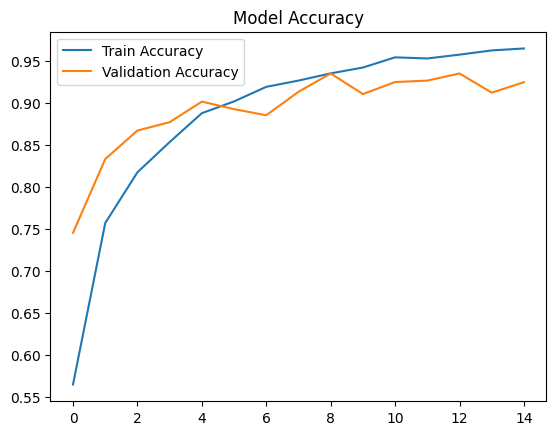

In [19]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

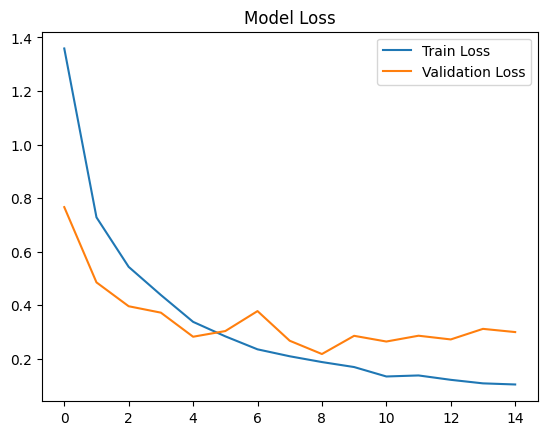

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

**Save Model**

In [21]:
# Save the model in the modern Keras format
model.save('plant_disease_model.keras')

print("Model saved successfully!")

Model saved successfully!


In [30]:
import pickle
with open('label_encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)

**Predict on Test Data**

In [31]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


**Confusion Matrix**

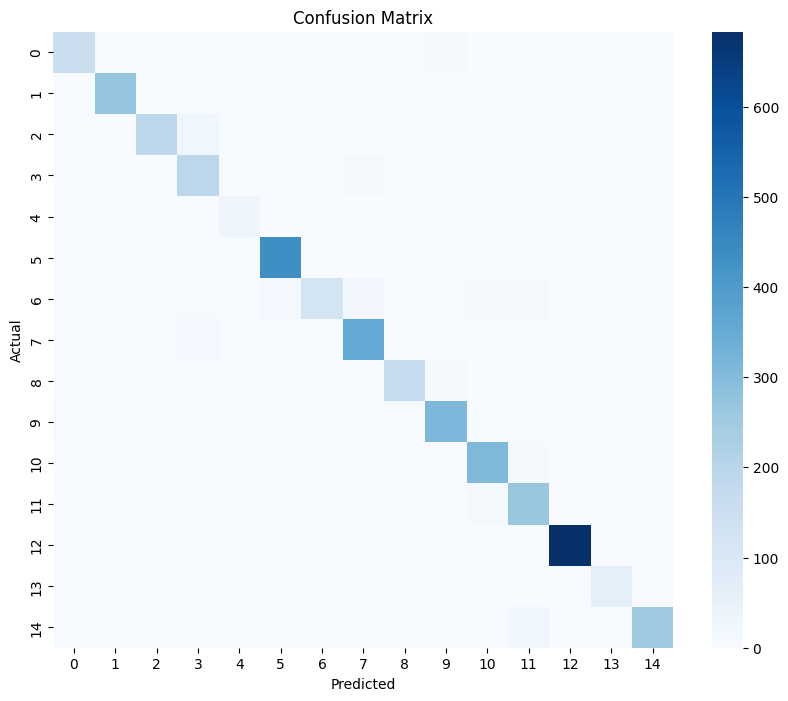

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Classification Report**

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=encoder.classes_))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.96      0.88      0.92       177
                     Pepper__bell___healthy       0.97      0.99      0.98       276
                      Potato___Early_blight       0.96      0.86      0.91       221
                       Potato___Late_blight       0.80      0.93      0.86       208
                           Potato___healthy       0.89      0.80      0.85        41
                      Tomato_Bacterial_spot       0.92      0.99      0.95       438
                        Tomato_Early_blight       0.91      0.64      0.75       192
                         Tomato_Late_blight       0.88      0.91      0.89       390
                           Tomato_Leaf_Mold       0.95      0.90      0.93       188
                  Tomato_Septoria_leaf_spot       0.90      0.93      0.91       336
Tomato_Spider_mites_Two_spotted_spider_mite       0.91      0.95

In [34]:
def predict_image(img):
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    return f"{encoder.classes_[class_index]} ({confidence*100:.2f}%)"

In [35]:
import gradio as gr
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="numpy"),
    outputs="text",
    title="🌿 Plant Disease Detection System",
    description="Upload a leaf image and detect plant disease using CNN"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e37d390ce7aa4d3e5d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
